# A logical progression through classic machine-learning models

The examples progress from simple decision boundaries to generalization, ensembles, regression, and class imbalance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, mean_absolute_error, r2_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBRegressor

## Shared visual helpers
These functions keep the dataset, decision-boundary, and regression plots visually consistent.

In [2]:
FEATURES_2D = ["x1", "x2"]


def plot_points(data, ax, title):
    for label, colour in [(0, "tab:blue"), (1, "tab:orange")]:
        rows = data[data["class"] == label]
        ax.scatter(rows["x1"], rows["x2"], c=colour, label=f"class {label}", alpha=0.7, edgecolors="white")
    ax.set(title=title, xlabel="x1", ylabel="x2")
    ax.legend()
    ax.grid(alpha=0.2)


def display_points(data, title, test=None):
    datasets = [("Observed data", data)] if test is None else [("Training data", data), ("Test data", test)]
    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharex=True, sharey=True, squeeze=False)
    for ax, (split_title, split_data) in zip(axes[0], datasets):
        plot_points(split_data, ax, split_title)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def display_classifications(model, train, title, test=None):
    datasets = [("Observed data", train)] if test is None else [("Training data", train), ("Test data", test)]
    combined = pd.concat([data for _, data in datasets])
    x1 = np.linspace(combined["x1"].min() - 0.5, combined["x1"].max() + 0.5, 250)
    x2 = np.linspace(combined["x2"].min() - 0.5, combined["x2"].max() + 0.5, 250)
    grid_x1, grid_x2 = np.meshgrid(x1, x2)
    grid = pd.DataFrame({"x1": grid_x1.ravel(), "x2": grid_x2.ravel()})
    probabilities = model.predict_proba(grid)[:, 1].reshape(grid_x1.shape)

    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharex=True, sharey=True, squeeze=False)
    for ax, (split_title, data) in zip(axes[0], datasets):
        ax.contourf(grid_x1, grid_x2, probabilities, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
        ax.contour(grid_x1, grid_x2, probabilities, levels=[0.5], colors="black", linewidths=2)
        plot_points(data, ax, split_title)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def fit_and_show(model, train, title, test=None):
    model.fit(train[FEATURES_2D], train["class"])
    train_accuracy = accuracy_score(train["class"], model.predict(train[FEATURES_2D]))
    if test is None:
        print(f"accuracy on observed data: {train_accuracy:.3f}")
    else:
        print(f"training accuracy: {train_accuracy:.3f}")
        test_accuracy = accuracy_score(test["class"], model.predict(test[FEATURES_2D]))
        print(f"accuracy on unseen test data: {test_accuracy:.3f}")
    display_classifications(model, train, title, test=test)
    return model


def display_regression_measurements(train, test):
    combined = pd.concat([train, test])
    vmin, vmax = combined["target"].min(), combined["target"].max()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True, constrained_layout=True)
    for ax, (title, data) in zip(axes, [("Training measurements", train), ("Test measurements", test)]):
        points = ax.scatter(data["x1"], data["x2"], c=data["target"], cmap="hot", vmin=vmin, vmax=vmax, s=12)
        ax.set(title=title, xlabel="x1", ylabel="x2")
    fig.colorbar(points, ax=axes, label="target", shrink=0.85)
    plt.show()


def display_regression_results(surface, predictions):
    x1 = surface["x1"].unique()
    x2 = surface["x2"].unique()
    grid_shape = (len(x2), len(x1))
    extent = [x1.min(), x1.max(), x2.min(), x2.max()]
    truth = surface["target"].to_numpy()
    vmin, vmax = truth.min(), truth.max()

    surfaces = [("True piecewise function", truth), *predictions.items()]
    fig, axes = plt.subplots(1, len(surfaces), figsize=(4.5 * len(surfaces), 4), constrained_layout=True)
    for ax, (title, values) in zip(axes, surfaces):
        image = ax.imshow(values.reshape(grid_shape), origin="lower", extent=extent, cmap="hot", vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
        ax.set(title=title, xlabel="x1", ylabel="x2")
    fig.colorbar(image, ax=axes, label="target", shrink=0.85)
    plt.show()

    absolute_errors = {name: np.abs(values - truth) for name, values in predictions.items()}
    error_max = max(errors.max() for errors in absolute_errors.values())
    fig, axes = plt.subplots(1, len(absolute_errors), figsize=(4.5 * len(absolute_errors), 4), constrained_layout=True)
    for ax, (name, errors) in zip(axes, absolute_errors.items()):
        image = ax.imshow(errors.reshape(grid_shape), origin="lower", extent=extent, cmap="Blues", vmin=0, vmax=error_max, aspect="equal", interpolation="nearest")
        ax.set(title=f"{name}: absolute error", xlabel="x1", ylabel="x2")
    fig.colorbar(image, ax=axes, label="absolute error |prediction - truth|", shrink=0.85)
    plt.show()

## Step 1: one straight boundary
Logistic regression is sufficient when one straight line separates the classes.

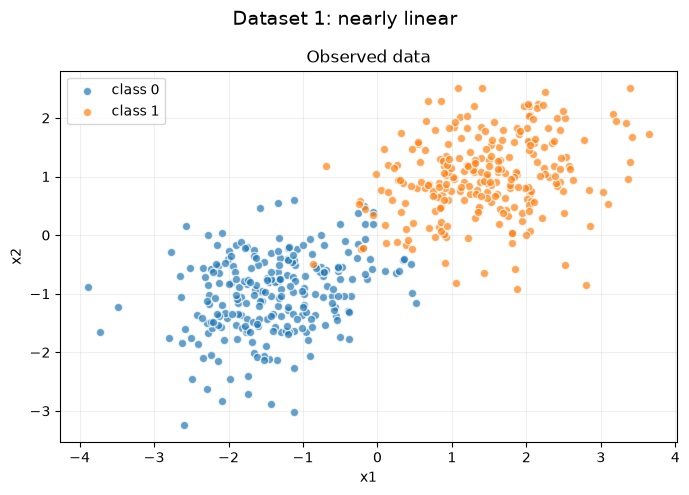

accuracy on observed data: 0.982


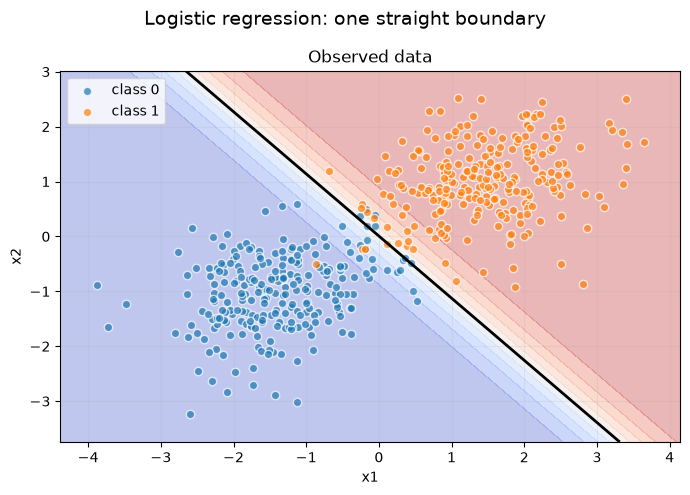

In [3]:
linear_data = pd.read_csv("data1_linear.csv")
display_points(linear_data, "Dataset 1: nearly linear")
fit_and_show(LogisticRegression(), linear_data, "Logistic regression: one straight boundary");

## Step 2: one line is not enough
XOR requires several cuts because opposite corners share a class.

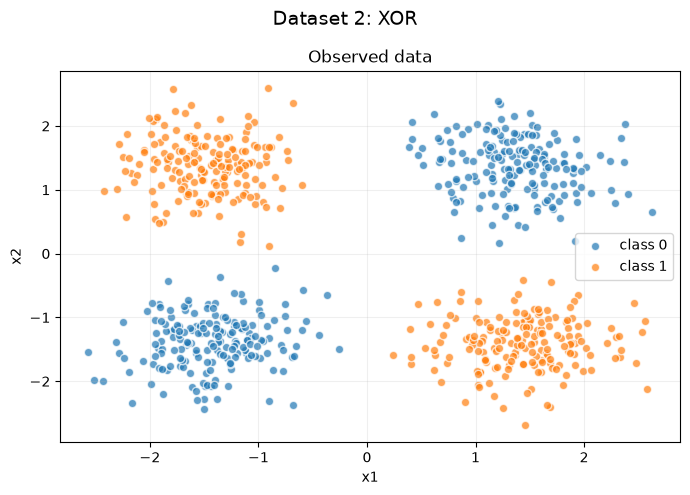

In [4]:
xor_data = pd.read_csv("data2_nonlinear.csv")
display_points(xor_data, "Dataset 2: XOR")

accuracy on observed data: 0.497


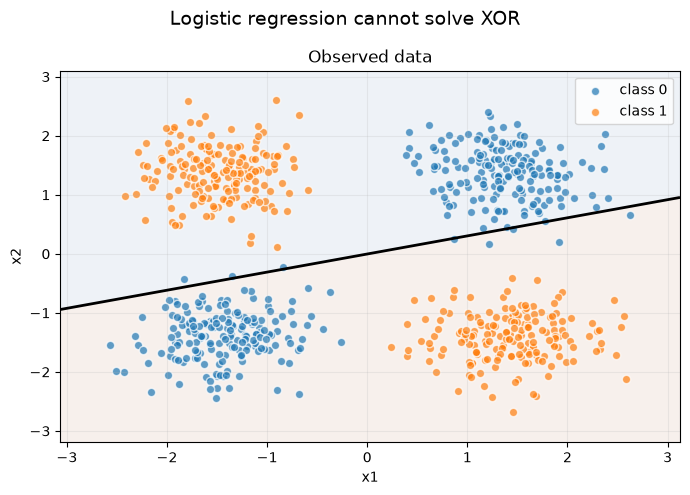

In [5]:
fit_and_show(LogisticRegression(), xor_data, "Logistic regression cannot solve XOR");

accuracy on observed data: 1.000


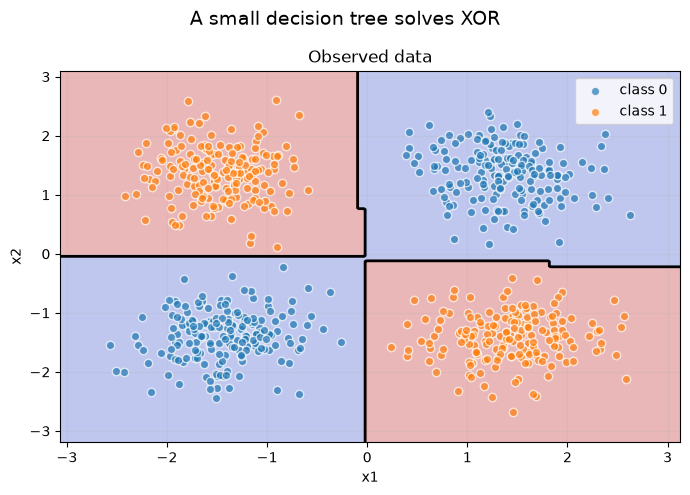

In [6]:
fit_and_show(
    DecisionTreeClassifier(max_depth=4, random_state=42),
    xor_data, "A small decision tree solves XOR"
);

## Step 3: training data versus unseen data
A held-out test set distinguishes memorization from generalization.

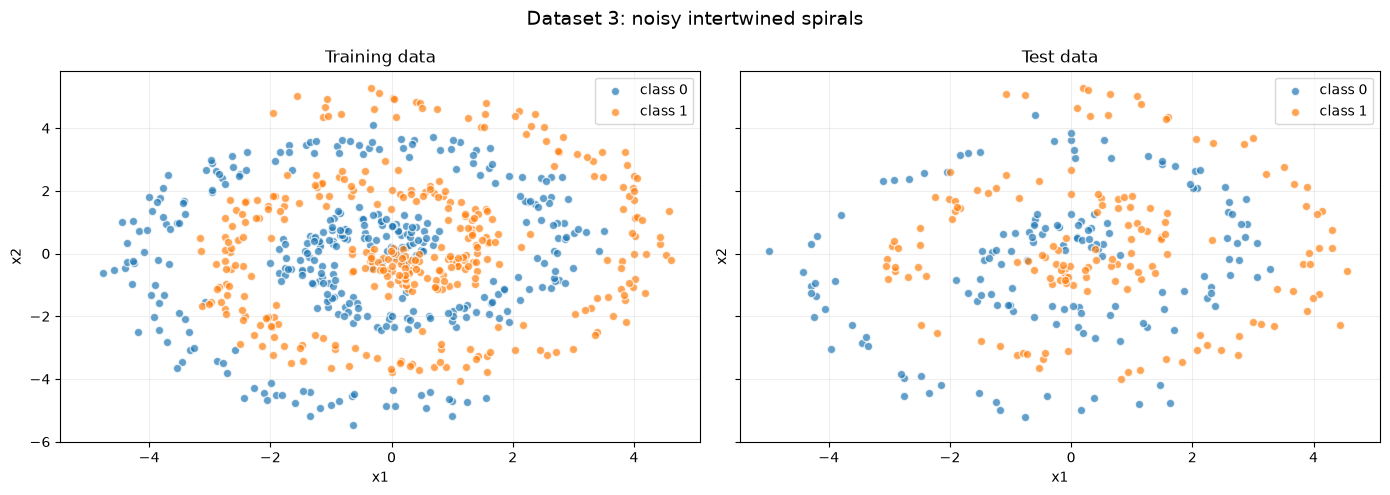

In [7]:
def split_data(data, test_size=0.3):
    return train_test_split(
        data, test_size=test_size, stratify=data["class"], random_state=42
    )


spiral_train, spiral_test = split_data(pd.read_csv("data3_spiral.csv"))
display_points(spiral_train, "Dataset 3: noisy intertwined spirals", spiral_test)

training accuracy: 1.000
accuracy on unseen test data: 0.917


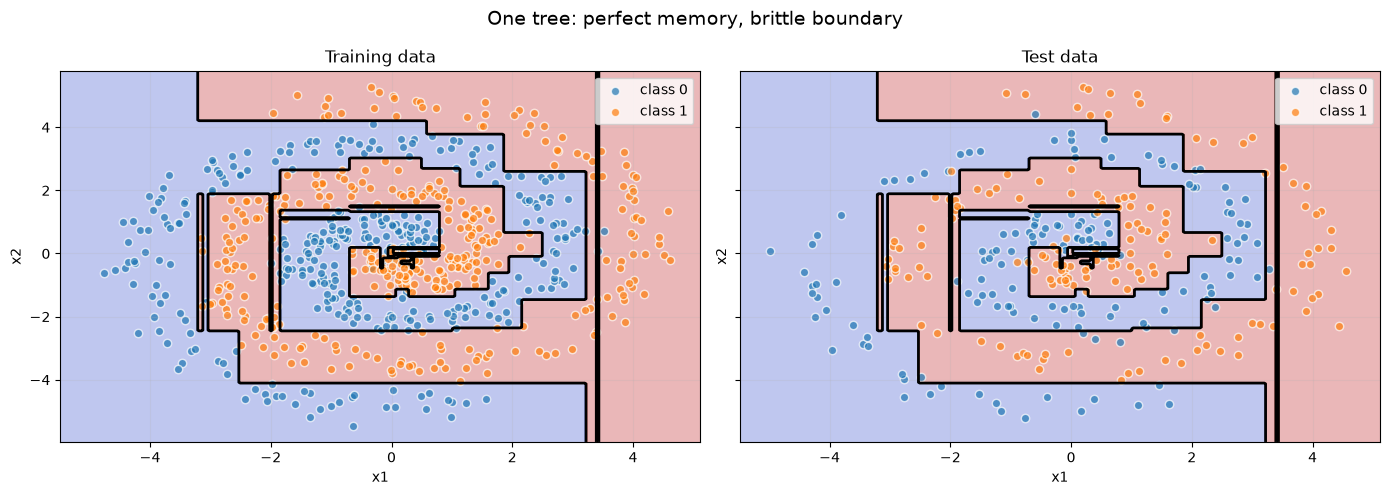

In [8]:
spiral_tree = fit_and_show(
    DecisionTreeClassifier(random_state=42),
    spiral_train, "One tree: perfect memory, brittle boundary", test=spiral_test
)

training accuracy: 1.000
accuracy on unseen test data: 0.943


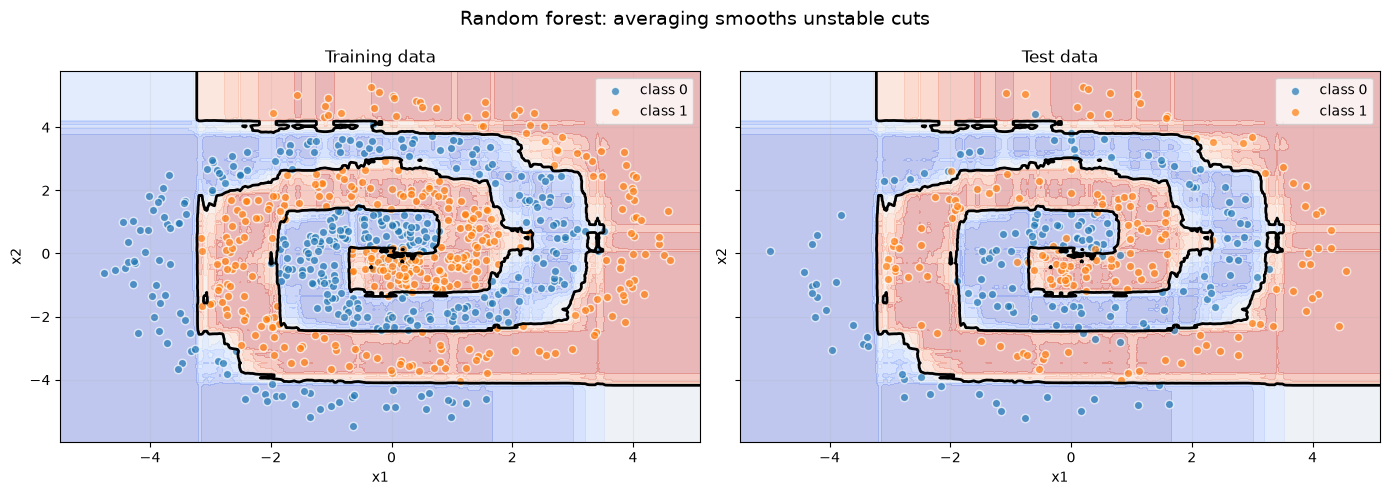

In [9]:
spiral_forest = fit_and_show(
    RandomForestClassifier(n_estimators=300,random_state=23, n_jobs=-1),
    spiral_train, "Random forest: averaging smooths unstable cuts", test=spiral_test
)

## Step 4: regression and residual correction
A piecewise-constant surface forms a face from distinct geometric regions.

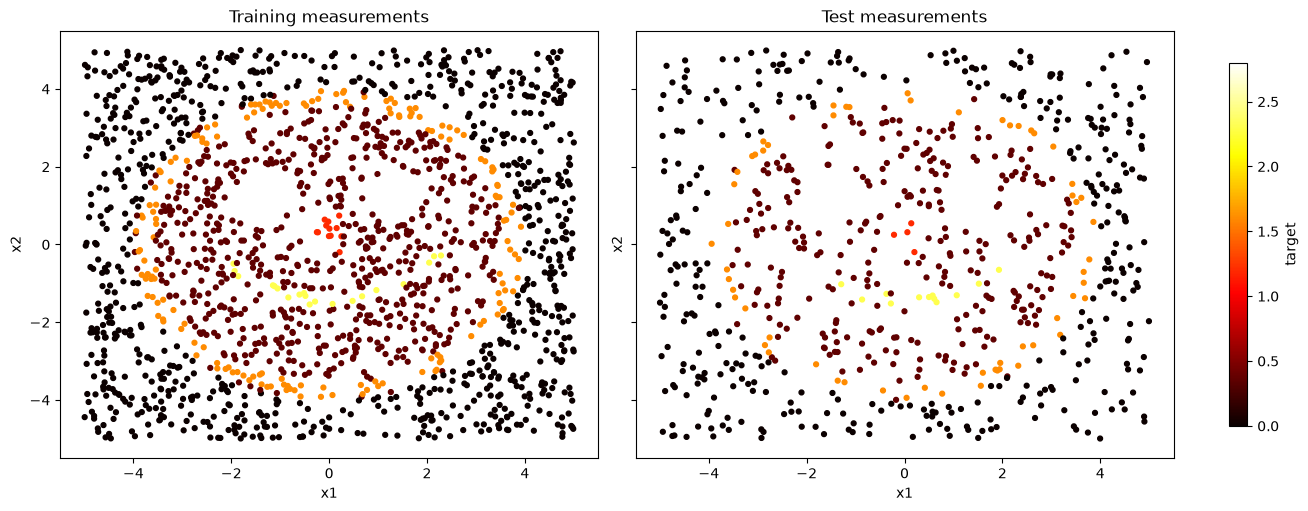

In [10]:
regression_data = pd.read_csv("data4_regression.csv")
regression_surface = pd.read_csv("data4_regression_surface.csv")
reg_train, reg_test = train_test_split(regression_data, test_size=0.3, random_state=23)
display_regression_measurements(reg_train, reg_test)

,test MAE (lower is better),test R2 (higher is better)
model,,
one tree,0.307,0.259
random forest,0.215,0.610
XGBoost,0.155,0.689
CatBoost,0.155,0.736


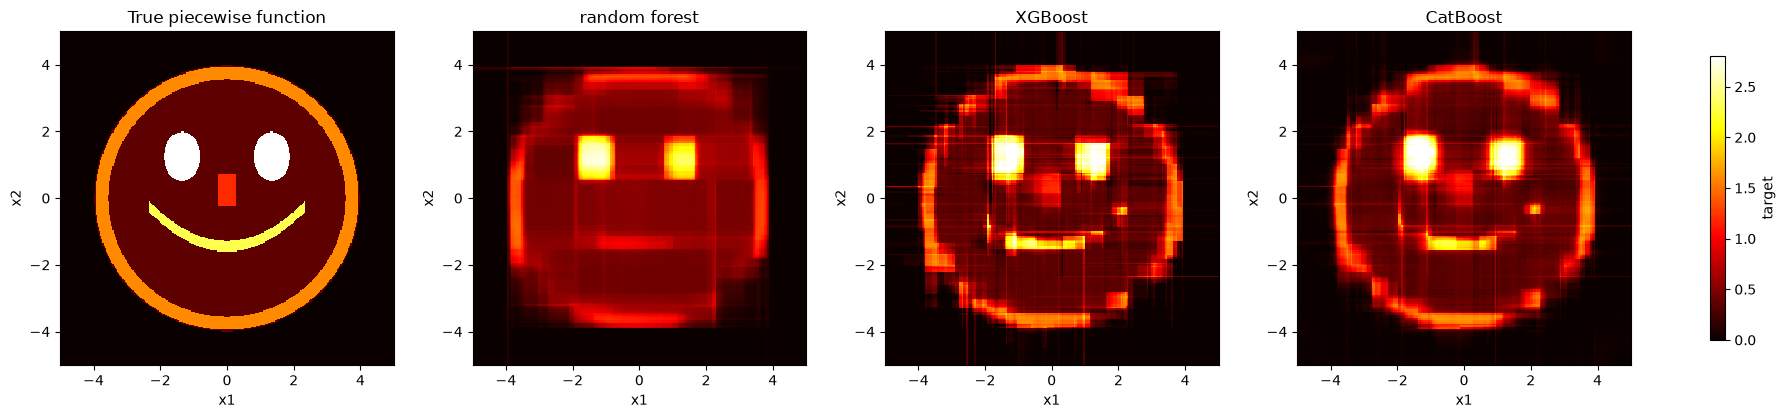

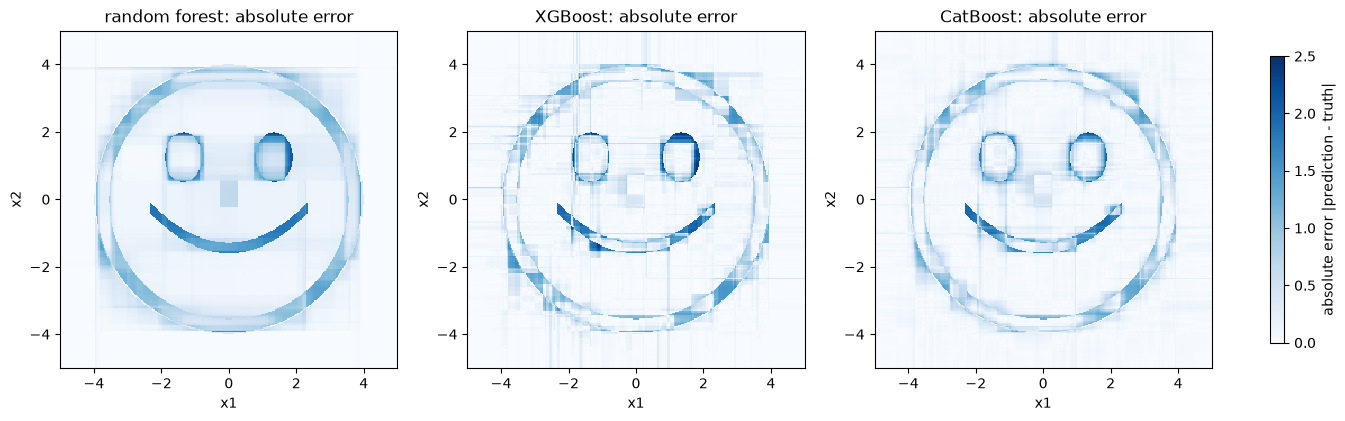

In [11]:
regression_models = {
    "one tree": DecisionTreeRegressor(max_depth=8, min_samples_leaf=4, random_state=42),
    "random forest": RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=1200, max_depth=7, learning_rate=0.03, subsample=0.9, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=1500, depth=10, learning_rate=0.04, loss_function="RMSE", random_seed=42, verbose=False, allow_writing_files=False),
}

rows = []
for name, model in regression_models.items():
    model.fit(reg_train[FEATURES_2D], reg_train["target"])
    rows.append({
        "model": name,
        "test MAE (lower is better)": mean_absolute_error(reg_test["target"], model.predict(reg_test[FEATURES_2D])),
        "test R2 (higher is better)": r2_score(reg_test["target"], model.predict(reg_test[FEATURES_2D])),
    })
display(pd.DataFrame(rows).set_index("model").round(3))

predicted_surfaces = {
    name: model.predict(regression_surface[FEATURES_2D])
    for name, model in regression_models.items()
    if name != "one tree"
}
display_regression_results(regression_surface, predicted_surfaces)

With sparse measurements, boosting's sequential corrections capture residual structure that the independently fitted forest trees miss.

## Step 5: accuracy can reward a useless model
High accuracy can hide poor minority-class performance when classes are imbalanced.

training class proportions:


class
0    0.95
1    0.05
Name: proportion, dtype: float64

test class proportions:


class
0    0.5
1    0.5
Name: proportion, dtype: float64

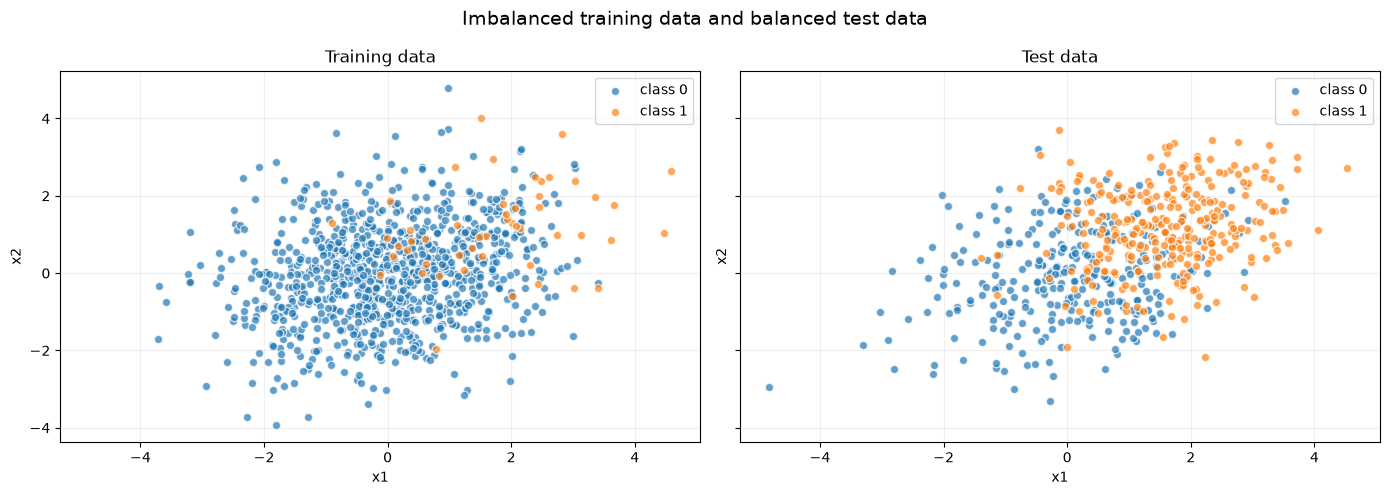

In [12]:
imbalanced_train = pd.read_csv("data5_imbalanced_train.csv")
imbalanced_test = pd.read_csv("data5_imbalanced_test.csv")
print("training class proportions:")
display(imbalanced_train["class"].value_counts(normalize=True).sort_index().rename("proportion"))
print("test class proportions:")
display(imbalanced_test["class"].value_counts(normalize=True).sort_index().rename("proportion"))
display_points(imbalanced_train, "Imbalanced training data and balanced test data", imbalanced_test)

In [13]:
imbalance_models = {
    "always no": DummyClassifier(strategy="constant", constant=0),
    "logistic regression": LogisticRegression(),
    "class-balanced logistic": LogisticRegression(class_weight="balanced"),
}

rows = []
for name, model in imbalance_models.items():
    model.fit(imbalanced_train[FEATURES_2D], imbalanced_train["class"])
    for split_name, data in [("train", imbalanced_train), ("test", imbalanced_test)]:
        predictions = model.predict(data[FEATURES_2D])
        rows.append({
            "model": name,
            "split": split_name,
            "accuracy": accuracy_score(data["class"], predictions),
            "balanced accuracy": balanced_accuracy_score(data["class"], predictions),
            "positive recall": recall_score(data["class"], predictions, zero_division=0),
        })
results = pd.DataFrame(rows)
results.set_index(["model", "split"]).round(3)

accuracy  balanced accuracy  positive recall
model                   split                                              
always no               train     0.950              0.500            0.000
                        test      0.500              0.500            0.000
logistic regression     train     0.955              0.569            0.140
                        test      0.538              0.538            0.080
class-balanced logistic train     0.782              0.753            0.720
                        test      0.807              0.807            0.817

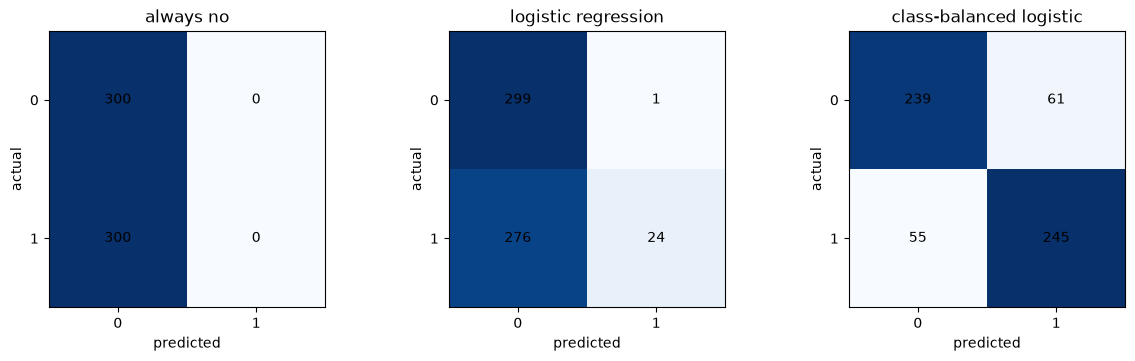

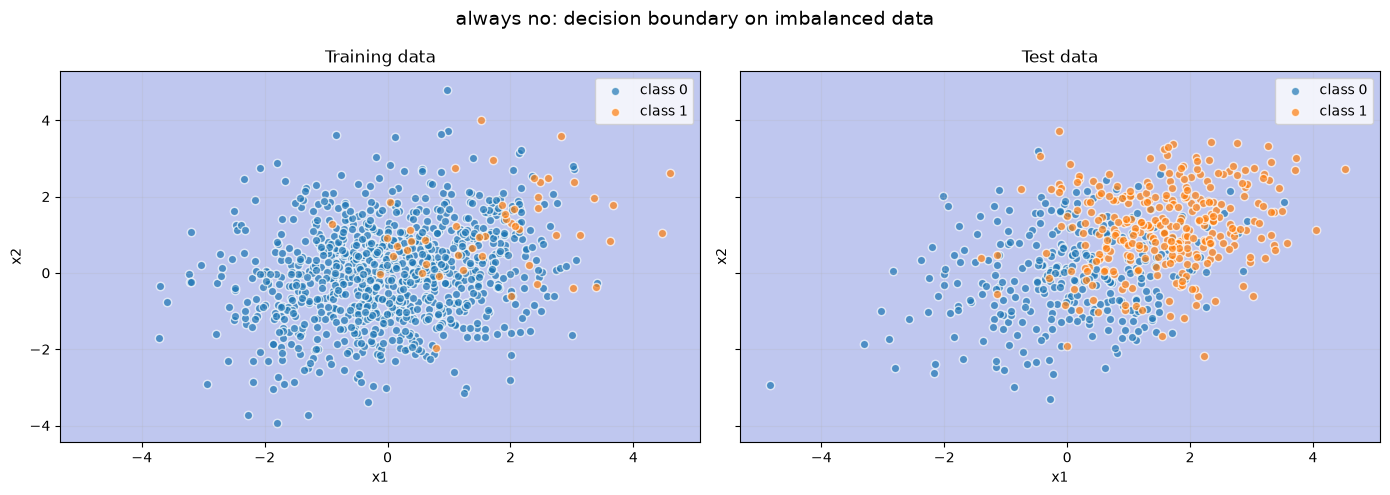

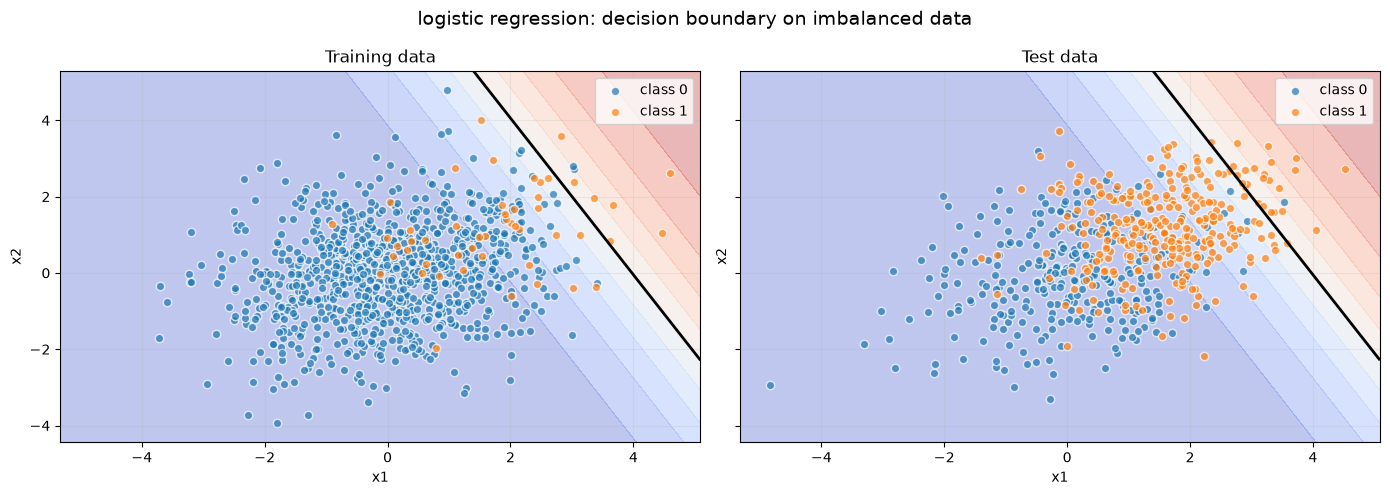

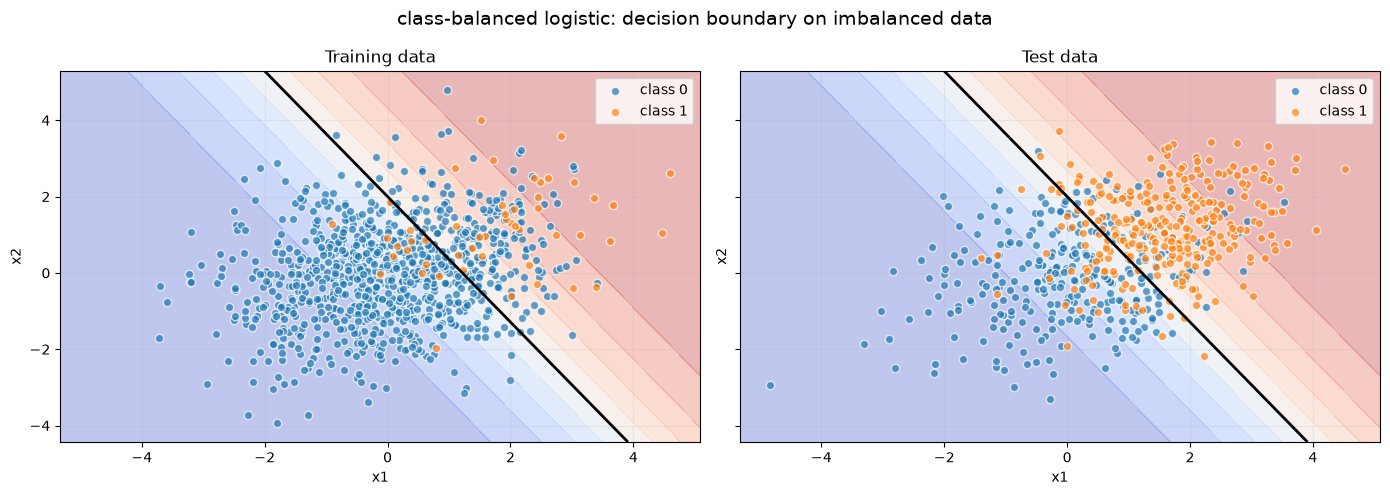

In [14]:
def plot_test_confusions(models):
    _, axes = plt.subplots(1, len(models), figsize=(12, 3.5), constrained_layout=True)
    for ax, (name, model) in zip(axes, models.items()):
        cm = confusion_matrix(imbalanced_test["class"], model.predict(imbalanced_test[FEATURES_2D]))
        ax.imshow(cm, cmap="Blues")
        ax.set(title=name, xlabel="predicted", ylabel="actual", xticks=[0, 1], yticks=[0, 1])
        for row in range(2):
            for column in range(2):
                ax.text(column, row, cm[row, column], ha="center", va="center")
    plt.show()


plot_test_confusions(imbalance_models)
for name, model in imbalance_models.items():
    display_classifications(
        model, imbalanced_train,
        f"{name}: decision boundary on imbalanced data",
        test=imbalanced_test,
    )

## Independent play
